In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [3]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

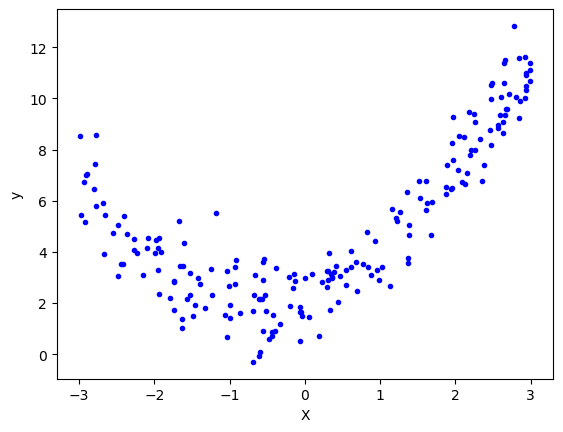

In [4]:
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [5]:
# Normal Linear Regression
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
# Applying Linear Regression
lr = LinearRegression()

In [7]:
lr.fit(X_train,y_train)

LinearRegression()

In [8]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.5098608918640611

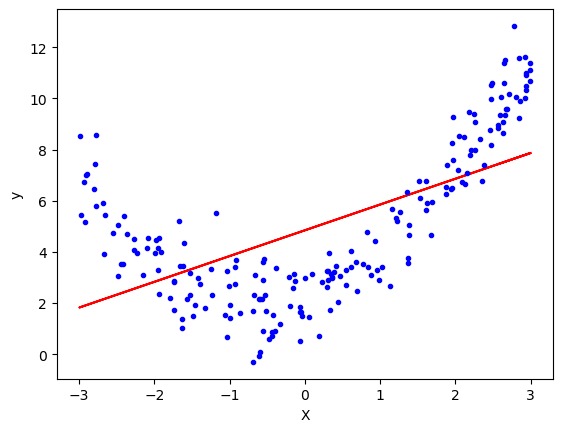

In [9]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [14]:
#Applying Polynomial Linear Regression
# degree 2
poly = PolynomialFeatures(degree=2, include_bias=True) # if we take include_bias = False we will remove the intercept value

X_train_trf = poly.fit_transform(X_train)
X_test_trf = poly.transform(X_test)

In [15]:
print(X_train[0])
print(X_train_trf[0])

[2.57088082]
[1.         2.57088082 6.60942821]


In [16]:
lr = LinearRegression()
lr.fit(X_train_trf, y_train)

LinearRegression()

In [17]:
y_pred = lr.predict(X_test_trf)

In [18]:
r2_score(y_test,y_pred)

0.9019195666819639

In [19]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.8423301  0.76629402]]
[2.29704697]


In [21]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

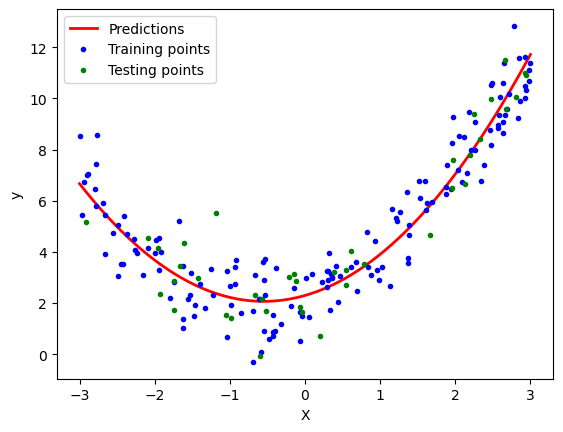

In [22]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()